In [1]:


# Cell 1: Setup and imports
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")



2026-04-13 14:37:19.860605: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Keras version: 3.10.0
Keras backend: tensorflow


In [2]:
# Cell 2: Load and prepare text data
# Load the Kalevala text
with open('../romeojuliet.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")



Text length: 184559 characters
First 100 characters: The Project Gutenberg eBook of Romeo and Juliet
    
This eBook is for the use of anyone anywhere in


In [3]:


# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'temp_romeojuliet.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train SentencePiece model
vocab_size = 10000  # You can adjust this based on your needs
model_prefix = 'romeojuliet_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,  # Important for Finnish
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "These violent delights have violent ends."
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")



Tokenized example: ['▁These', '▁violent', '▁delights', '▁have', '▁violent', '▁ends', '.']
Vocabulary size: 10000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: temp_romeojuliet.txt
  input_format: 
  model_prefix: romeojuliet_sp
  model_type: BPE
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <PAD>
  user_defined_symbols: <UNK>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece:

In [4]:
# Cell 4: Prepare training data
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i+seq_length+1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

) LOG(INFO) Updating active symbols. max_freq=3 min_freq=2
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=3 size=3220 all=9920 active=984 piece=▁mission
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=3 size=3240 all=9909 active=973 piece=▁backward
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=3 size=3260 all=9892 active=956 piece=▁physical
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=3 size=3280 all=9873 active=937 piece=▁hypertext
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=3 size=3300 all=9854 active=918 piece=▁paragraphs
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=3 min_freq=2
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2 size=3320 all=9853 active=1000 piece=OS
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2 size=3340 all=9859 active=1006 piece=CLA
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2 size=3360 all=9873 active=1020 piece=bey
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2 size=3380 all=9897 active=1044 piece=ops
bpe_model_tra

Total tokens: 39951
Number of sequences: 39887
Input shape: (39887, 64)
Target shape: (39887, 64)


iner.cc(268) LOG(INFO) Added: freq=1 size=4820 all=9479 active=1001 piece=ughty
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4840 all=9473 active=995 piece=▁Rece
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4860 all=9461 active=983 piece=▁dust
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4880 all=9453 active=975 piece=▁lace
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4900 all=9443 active=965 piece=▁runs
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=1 min_freq=1
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4920 all=9441 active=999 piece=▁(~),
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4940 all=9430 active=988 piece=▁warn
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4960 all=9424 active=982 piece=alyzed
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=4980 all=9420 active=978 piece=gthens
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1 size=5000 all=9418 active=976 piece=pening
bpe_mo

In [5]:


# Cell 5: Define the model
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

# Define model parameters
embed_dim = 192
num_heads = 4
ff_dim = 384
num_layers = 2

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

2026-04-13 14:37:23.308914: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-13 14:37:23.315847: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-13 14:37:23.316033: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 192)   │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 192)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 192)   │        384 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 10000) │  1,930,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,444,048 (16.95 MB)

 Trainable params: 4,444,048 (16.95 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:


# Cell 6: Train the model
batch_size = 128
epochs = 100

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('romeojuliet_bestmodel.keras', save_best_only=True)
    ]
)

Epoch 1/100


I0000 00:00:1776080248.694271   54110 service.cc:145] XLA service 0x20d1e210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776080248.694315   54110 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2026-04-13 14:37:28.824511: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1776080249.112426   54110 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-04-13 14:37:29.512547: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


  1/250 ━━━━━━━━━━━━━━━━━━━━ 1:01:33 15s/step - accuracy: 0.0000e+00 - loss: 9.2215

I0000 00:00:1776080259.246363   54110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.0472 - loss: 8.4542

W0000 00:00:1776080296.449313   54112 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.0473 - loss: 8.4516

W0000 00:00:1776080305.630121   54110 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1776080309.532493   54110 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


250/250 ━━━━━━━━━━━━━━━━━━━━ 67s 208ms/step - accuracy: 0.0473 - loss: 8.4491 - val_accuracy: 0.0672 - val_loss: 6.8193 - learning_rate: 5.0000e-05
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.0689 - loss: 6.6569 - val_accuracy: 0.0694 - val_loss: 6.4282 - learning_rate: 5.0000e-05
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.0700 - loss: 6.4205 - val_accuracy: 0.0840 - val_loss: 6.3954 - learning_rate: 5.0000e-05
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.0850 - loss: 6.3722 - val_accuracy: 0.1180 - val_loss: 6.0792 - learning_rate: 5.0000e-05
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.1268 - loss: 5.9536 - val_accuracy: 0.1499 - val_loss: 5.5083 - learning_rate: 5.0000e-05
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.1602 - loss: 5.4361 - val_accuracy: 0.1967 - val_loss: 5.0658 - learning_rate: 5.0000e-05
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/s

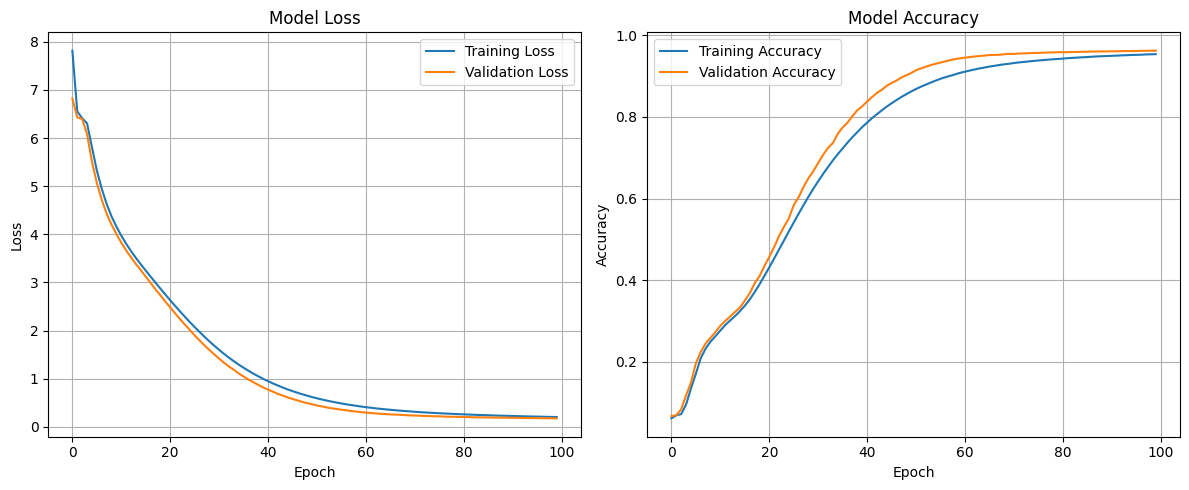

In [7]:
# Cell 7: Plot training metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
model.save('romeojuliet_model.keras')

In [9]:


def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text



With strict 0.2 temperature we can see that the text generated from the seed prompts are 1:1 with the book.

For example, first seed prompt from the book:

    "Two households, both alike in dignity,
    In fair Verona, where we lay our scene,
    From ancient grudge break to new mutiny,
    Where civil blood makes civil hands unclean.
    From forth the fatal loins of these two foes
    A pair of star-cross'd lovers take their life;
    Whose misadventur'd piteous overthrows
    Doth with their death bury their parents' strife.
    The fearful passage of their death-mark'd love,
    And the continuance of their parents' rage,
    Which, but their children's end, naught could remove,
    Is now the two hours' traffic of our stage;"



In [10]:
prompts = [
    "Two households, both alike in dignity,",
    "But, soft! what light through yonder window breaks?",
    "O Romeo, Romeo! wherefore art thou Romeo?",
    "O, then, I see Queen Mab hath been with you.",
    "What, drawn, and talk of peace! I hate the word,",
    "A plague o' both your houses!"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.2)
    print(generated)


Prompt: Two households, both alike in dignity,
Two households, both alike in dignity, In fair Verona, where we lay our scene, From ancient grudge break to new mutiny, Where civil blood makes civil hands unclean. From forth the fatal loins of these two foes A pair of star-cross'd lovers take their life; Whose misadventur'd piteous overthrows Doth with their death bury their parents' strife. The fearful passage of their death-mark'd love, And the continuance of their parents' rage, Which, but their children's end, naught could remove, Is now

Prompt: But, soft! what light through yonder window breaks?
But, soft! what light through yonder window breaks? It is the East, and Juliet is the sun! Arise, fair sun, and kill the envious moon, Who is already sick and pale with grief That thou her maid art far more fair than she. Be not her maid, since she is envious. Her vestal livery is but sick and green, And none but fools do wear it. Cast it off. It is my lady; O, it is my love! O that she kn

With temperature set to 2.0:

In [12]:
for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=2.0)
    print(generated)


Prompt: Two households, both alike in dignity,
Two households, both alike in dignity, In fair Verona, counsel, those that shall die. Rom. Wife. She's not fourteen. Nurse. Well, marry; I remember it well. Being a noise did to cherish; Thy wit is grown: Either what a gossip's fair fate, Turning his foul walks of the Watch.] Pitiful sight! the County lies on the tomb. Section addresses. dovehouse! I descend strength shall say Wilt thouTM) Library Inc.) YOU Phaeton would whip the lodging! of Montague of wax

Prompt: But, soft! what light through yonder window breaks?
But, soft! what light through yonder window breaks? It is the East, hypertext form, format other than Prince God below, As one dead bodies. I hold Mus. spent The research. Ay, you paid for a case may think liberty unto sland'd. Jul. It may be so, except by thy terms of true Wilt and provoke me like things sore enpierced with his shaft To soar with his light FITN sweeting; it were a most sharp sauce. Rom. And is it not, here! 